In [11]:
# Cell 1: Imports

import os
from pathlib import Path
import math

import ipywidgets as widgets
from IPython.display import display

%matplotlib widget

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

from scipy.spatial.distance import cdist 
from scipy import linalg
import scipy.linalg
from scipy.ndimage import map_coordinates

print("numpy:", np.__version__)
print("PIL:", Image.__version__)
print("cv2:", cv2.__version__)
print("SciPy loaded successfully.")

numpy: 2.2.6
PIL: 10.2.0
cv2: 4.12.0
SciPy loaded successfully.


In [2]:
# Cell 2: Simplified Path Setup

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"

# Only create paths we actually need
DATA_RAW = DATA_DIR / "raw" / "OriginalImages"
DATA_LANDMARKS = DATA_DIR / "landmarks"
DATA_ALIGNED = DATA_DIR / "aligned"

# Create only essential directories
DATA_LANDMARKS.mkdir(parents=True, exist_ok=True)
DATA_ALIGNED.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_RAW:", DATA_RAW)
print("DATA_LANDMARKS:", DATA_LANDMARKS)
print("DATA_ALIGNED:", DATA_ALIGNED)
print("\n✓ Path setup complete")

PROJECT_ROOT: D:\Projects 2025\Caricature Generation
DATA_RAW: D:\Projects 2025\Caricature Generation\data\raw\OriginalImages
DATA_LANDMARKS: D:\Projects 2025\Caricature Generation\data\landmarks
DATA_ALIGNED: D:\Projects 2025\Caricature Generation\data\aligned

✓ Path setup complete


In [3]:
# Cell 3: Essential helper functions only

def load_landmarks(p):
    """Load landmarks from .npy file."""
    p = Path(p)
    if not p.exists():
        return None
    try:
        arr = np.load(str(p))
        if arr.ndim == 2 and arr.shape[1] == 2:
            return arr.astype(np.float32)
    except Exception as e:
        print(f"Error loading {p.name}: {e}")
    return None

def collect_photo_files(root_dir, limit=None):
    """Collect image files starting with 'p'."""
    files = []
    for img_path in root_dir.rglob('*'):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp'}:
            continue
        if not img_path.stem.lower().startswith('p'):
            continue
        files.append(img_path)
        if limit and len(files) >= limit:
            break
    return files

def bbox_diag(pts):
    """Calculate bounding box diagonal."""
    xs, ys = pts[:, 0], pts[:, 1]
    return np.linalg.norm([xs.max() - xs.min(), ys.max() - ys.min()])

def normalize_shape(pts):
    """Center and scale landmarks to unit size."""
    centroid = pts.mean(axis=0)
    scale = bbox_diag(pts)
    if scale < 1e-6:
        scale = 1.0
    return (pts - centroid) / scale

print("✓ Helper functions defined")

✓ Helper functions defined


In [4]:
# Cell 4: Landmark extraction
import face_alignment
from face_alignment import LandmarksType

DEMO_LIMIT = 100
DEVICE = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'

fa = face_alignment.FaceAlignment(LandmarksType.TWO_D, device=DEVICE, flip_input=False)

def get_largest_face(landmarks_list):
    """Return index of largest face."""
    areas = []
    for pts in landmarks_list:
        w = pts[:, 0].max() - pts[:, 0].min()
        h = pts[:, 1].max() - pts[:, 1].min()
        areas.append(w * h)
    return int(np.argmax(areas))

# Process images
all_files = collect_photo_files(DATA_RAW, DEMO_LIMIT)
print(f"Found {len(all_files)} images to process")

count_ok = 0
count_fail = 0

for img_path in tqdm(all_files, desc="Extracting landmarks"):
    rel_path = img_path.relative_to(DATA_RAW)
    out_path = DATA_LANDMARKS / rel_path.with_suffix('.npy')
    
    # Skip if already processed
    if out_path.exists():
        continue
    
    try:
        img = np.array(Image.open(img_path).convert('RGB'))
        preds = fa.get_landmarks(img)
        
        if preds is None or len(preds) == 0:
            count_fail += 1
            continue
        
        # Get largest face
        face_idx = get_largest_face(preds)
        pts = preds[face_idx].astype(np.float32)
        
        # Save landmarks only
        out_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(str(out_path), pts)
        count_ok += 1
        
    except Exception as e:
        count_fail += 1
        continue

print(f"\n{'='*60}")
print(f"✓ Success: {count_ok}")
print(f"✗ Failed: {count_fail}")
print(f"{'='*60}")

Found 100 images to process


Extracting landmarks: 100%|███████████████████████████████████████████████████████| 100/100 [00:00<00:00, 12493.83it/s]


✓ Success: 0
✗ Failed: 0


Scanning D:\Projects 2025\Caricature Generation\data\landmarks for landmarks...
Found 100 files. Using 100 shapes with 68 points.
✓ Saved to: D:\Projects 2025\Caricature Generation\data\aligned\mean_shape.npy


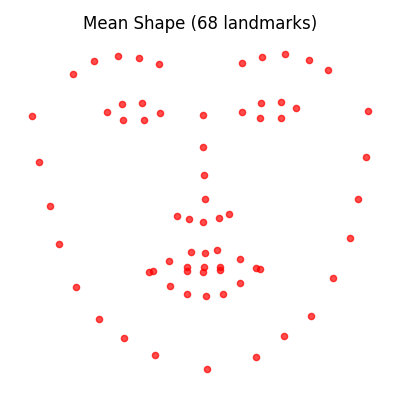

In [5]:
# Cell 5: Build mean normalized shape - single file output
MIN_LANDMARKS = 5
MEAN_SHAPE_PATH = DATA_ALIGNED / "mean_shape.npy"
DATA_ALIGNED.mkdir(parents=True, exist_ok=True)

def build_mean_shape(landmark_root=DATA_LANDMARKS):
    """Build mean normalized shape from landmarks."""
    all_norms = []
    counts = {}
    
    print(f"Scanning {landmark_root} for landmarks...")
    
    for lm_path in landmark_root.rglob("*.npy"):
        if not lm_path.stem.lower().startswith('p'):
            continue
        
        try:
            pts = np.load(str(lm_path))
            if pts.ndim != 2 or pts.shape[1] != 2 or pts.shape[0] < MIN_LANDMARKS:
                continue
            
            all_norms.append(normalize_shape(pts))
            counts[pts.shape[0]] = counts.get(pts.shape[0], 0) + 1
        except:
            continue
    
    if len(all_norms) == 0:
        raise RuntimeError("No valid landmarks found!")
    
    # Use most common landmark count
    common_n = max(counts, key=counts.get)
    final_norms = [n for n in all_norms if n.shape[0] == common_n]
    
    print(f"Found {len(all_norms)} files. Using {len(final_norms)} shapes with {common_n} points.")
    
    # Compute mean
    mean_norm = np.mean(np.stack(final_norms, axis=0), axis=0)
    np.save(MEAN_SHAPE_PATH, mean_norm)
    print(f"✓ Saved to: {MEAN_SHAPE_PATH}")
    
    return mean_norm

mean_norm = build_mean_shape()

# Visualize
plt.figure(figsize=(4, 4))
plt.scatter(mean_norm[:, 0], -mean_norm[:, 1], s=20, c='red', alpha=0.7)
plt.axis('equal')
plt.axis('off')
plt.title(f"Mean Shape ({len(mean_norm)} landmarks)")
plt.tight_layout()
plt.show()

In [6]:
# Cell 6: Create canonical target and transform utilities
OUTPUT_SIZE = (256, 256)
TARGET_FACE_SCALE = 0.45
TARGET_PTS_PATH = DATA_ALIGNED / "target_pts.npy"

# Load or use existing mean
if MEAN_SHAPE_PATH.exists():
    mean_norm = np.load(str(MEAN_SHAPE_PATH))
else:
    raise RuntimeError("Mean shape not found. Run Cell 5 first.")

# Create target points
w_out, h_out = OUTPUT_SIZE
center_out = np.array([w_out/2.0, h_out/2.0], dtype=np.float32)
target_scale = min(w_out, h_out) * TARGET_FACE_SCALE
target_pts = (mean_norm * target_scale + center_out).astype(np.float32)
np.save(str(TARGET_PTS_PATH), target_pts)
print(f"✓ Saved target_pts: {TARGET_PTS_PATH}")

def estimate_transform(src_pts, dst_pts, method='affine'):
    """Estimate transform with fallback strategies."""
    src = np.asarray(src_pts, dtype=np.float32)
    dst = np.asarray(dst_pts, dtype=np.float32)
    
    # Try RANSAC
    try:
        if method == 'affine':
            M, _ = cv2.estimateAffine2D(src, dst, method=cv2.RANSAC, 
                                        ransacReprojThreshold=5.0, maxIters=2000)
        else:
            M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC,
                                               ransacReprojThreshold=5.0, maxIters=2000)
        if M is not None:
            return M
    except:
        pass
    
    # Try LMEDS
    try:
        if method == 'affine':
            M, _ = cv2.estimateAffine2D(src, dst, method=cv2.LMEDS)
        else:
            M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
        if M is not None:
            return M
    except:
        pass
    
    # Fallback: simple similarity
    src_center = src.mean(axis=0)
    dst_center = dst.mean(axis=0)
    src_scale = np.sqrt(((src - src_center) ** 2).sum() / len(src))
    dst_scale = np.sqrt(((dst - dst_center) ** 2).sum() / len(dst))
    scale = dst_scale / (src_scale + 1e-8)
    
    M = np.array([
        [scale, 0, dst_center[0] - scale * src_center[0]],
        [0, scale, dst_center[1] - scale * src_center[1]]
    ], dtype=np.float32)
    
    return M

def transform_landmarks(pts, M):
    """Apply 2x3 affine matrix to landmarks."""
    pts = np.asarray(pts, dtype=np.float32)
    ones = np.ones((pts.shape[0], 1), dtype=np.float32)
    homog = np.concatenate([pts, ones], axis=1)
    return homog @ M.T

print("✓ Transform functions ready")

✓ Saved target_pts: D:\Projects 2025\Caricature Generation\data\aligned\target_pts.npy
✓ Transform functions ready


In [7]:
# Cell 7: Align images with hair preservation
ALIGNMENT_METHOD = 'affine'
CROP_STRATEGY = 'adaptive'
FACE_SCALE = 0.45
BG_FILL = (30, 30, 30)

def get_face_bbox_with_hair(pts, strategy='adaptive'):
    """Calculate bbox including hair region."""
    x_min, y_min = pts.min(axis=0)
    x_max, y_max = pts.max(axis=0)
    
    width = x_max - x_min
    height = y_max - y_min
    
    # Estimate hair region using anatomical proportions
    if len(pts) >= 27:
        eyebrow_top = pts[17:27, 1].min()
        jaw_bottom = pts[8, 1] if len(pts) > 8 else y_max
        face_height = jaw_bottom - eyebrow_top
        head_top_estimate = eyebrow_top - (face_height * 0.75)
    else:
        head_top_estimate = y_min - (height * 0.5)
    
    # Strategy-based padding
    if strategy == 'tight':
        pad_top = max(0, y_min - head_top_estimate) + height * 0.1
        pad_bottom = height * 0.1
        pad_x = width * 0.15
    elif strategy == 'adaptive':
        pad_top = max(0, y_min - head_top_estimate) + height * 0.25
        pad_bottom = height * 0.15
        pad_x = width * 0.25
    else:  # loose
        pad_top = max(0, y_min - head_top_estimate) + height * 0.45
        pad_bottom = height * 0.2
        pad_x = width * 0.35
    
    return [x_min - pad_x, y_min - pad_top, x_max + pad_x, y_max + pad_bottom]

def crop_and_align(img, pts, output_size, face_scale=0.45, crop_strategy='adaptive'):
    """Crop face with hair and align."""
    h_img, w_img = img.shape[:2]
    w_out, h_out = output_size
    
    # Get bbox
    bbox = get_face_bbox_with_hair(pts, strategy=crop_strategy)
    x_min, y_min, x_max, y_max = bbox
    
    # Clamp to image bounds
    x_min = max(0, int(x_min))
    y_min = max(0, int(y_min))
    x_max = min(w_img, int(x_max))
    y_max = min(h_img, int(y_max))
    
    # Crop
    cropped_img = img[y_min:y_max, x_min:x_max]
    cropped_pts = pts - np.array([x_min, y_min])
    
    # Calculate transform
    crop_center = np.array([cropped_img.shape[1] / 2, cropped_img.shape[0] / 2])
    target_center = np.array([w_out / 2, h_out / 2])
    
    face_w = cropped_pts[:, 0].max() - cropped_pts[:, 0].min()
    face_h = cropped_pts[:, 1].max() - cropped_pts[:, 1].min()
    target_scale = (min(w_out, h_out) * face_scale) / max(face_w, face_h)
    
    pts_centered = cropped_pts - crop_center
    target_pts_temp = pts_centered * target_scale + target_center
    
    M = estimate_transform(cropped_pts, target_pts_temp, method=ALIGNMENT_METHOD)
    
    # Warp
    warped = cv2.warpAffine(cropped_img, M, (w_out, h_out),
                            flags=cv2.INTER_LINEAR,
                            borderMode=cv2.BORDER_CONSTANT,
                            borderValue=BG_FILL)
    
    transformed_pts = transform_landmarks(cropped_pts, M)
    
    return warped, M, transformed_pts

# Process all images
raw_images = collect_photo_files(DATA_RAW, DEMO_LIMIT)
print(f"Found {len(raw_images)} images to align")

count_ok = 0
count_skipped = 0

for img_path in tqdm(raw_images, desc="Aligning with hair"):
    rel_path = img_path.relative_to(DATA_RAW)
    stem = rel_path.stem
    
    lm_src = DATA_LANDMARKS / rel_path.with_suffix('.npy')
    out_img = DATA_ALIGNED / f"{stem}_aligned.png"
    out_lm = DATA_ALIGNED / f"{stem}_aligned.npy"
    out_M = DATA_ALIGNED / f"{stem}_affine.npy"
    
    if not lm_src.exists():
        continue
    
    if out_img.exists() and out_lm.exists() and out_M.exists():
        count_skipped += 1
        continue
    
    try:
        src_pts = np.load(str(lm_src)).astype(np.float32)
        img = np.array(Image.open(img_path).convert('RGB'))
        
        warped, M, transformed_pts = crop_and_align(
            img, src_pts, OUTPUT_SIZE,
            face_scale=FACE_SCALE,
            crop_strategy=CROP_STRATEGY
        )
        
        out_img.parent.mkdir(parents=True, exist_ok=True)
        Image.fromarray(warped).save(str(out_img))
        np.save(str(out_lm), transformed_pts.astype(np.float32))
        np.save(str(out_M), M.astype(np.float32))
        
        count_ok += 1
    except Exception as e:
        continue

print(f"\n{'='*60}")
print(f"✓ Aligned: {count_ok}")
print(f"○ Skipped: {count_skipped}")
print(f"Output: {DATA_ALIGNED}")
print(f"{'='*60}")

Found 100 images to align


Aligning with hair: 100%|██████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 6249.99it/s]


✓ Aligned: 0
○ Skipped: 100
Output: D:\Projects 2025\Caricature Generation\data\aligned


In [8]:
# # Cell 8: Identity-Preserving TPS Core Functions
# import warnings
# import scipy.linalg

# REG = 1e-2
# GRID_STEP = 2

# # Facial feature pairs for symmetry constraints
# SYMMETRY_PAIRS = [
#     (list(range(17, 22)), list(range(22, 27))),  # Eyebrows
#     (list(range(36, 42)), list(range(42, 48))),  # Eyes
#     ([48, 49, 50], [54, 53, 52]),  # Upper lip
#     ([60, 61, 62], [64, 63, 62]),  # Lower lip
# ]

# def _tps_kernel(r):
#     """TPS radial basis function: r^2 * log(r)."""
#     out = np.zeros_like(r, dtype=np.float64)
#     nz = r > 0
#     out[nz] = (r[nz]**2) * np.log(r[nz])
#     return out

# def solve_tps(ctrl_pts, target_vals, reg=1e-2):
#     """Solve TPS interpolation coefficients."""
#     N = ctrl_pts.shape[0]
#     diff = ctrl_pts[:, None, :] - ctrl_pts[None, :, :]
#     r = np.sqrt((diff**2).sum(axis=2))
#     K = _tps_kernel(r)
#     P = np.concatenate([np.ones((N, 1)), ctrl_pts], axis=1)
    
#     A = np.zeros((N + 3, N + 3), dtype=np.float64)
#     A[:N, :N] = K + reg * np.eye(N)
#     A[:N, N:] = P
#     A[N:, :N] = P.T
    
#     rhs = np.zeros((N + 3,), dtype=np.float64)
#     rhs[:N] = target_vals.astype(np.float64)
    
#     with warnings.catch_warnings():
#         warnings.simplefilter("ignore")
#         coeffs = scipy.linalg.solve(A, rhs, assume_a='sym')
    
#     return coeffs[:N], coeffs[N:]

# def tps_eval_grid(ctrl_pts, w, a, xs, ys):
#     """Evaluate TPS on a grid."""
#     XX, YY = np.meshgrid(xs, ys)
#     pts = np.stack([XX.ravel(), YY.ravel()], axis=1)
#     diff = pts[:, None, :] - ctrl_pts[None, :, :]
#     r = np.sqrt((diff**2).sum(axis=2))
#     U = _tps_kernel(r)
#     fflat = U.dot(w) + a[0] + a[1]*pts[:, 0] + a[2]*pts[:, 1]
#     return fflat.reshape(len(ys), len(xs))

# def gaussian_rbf(distance, sigma):
#     """Gaussian RBF kernel."""
#     return np.exp(-(distance**2) / (2 * sigma**2))

# # Canvas expansion functions
# def expand_canvas(img, pts, scale=1.5):
#     """Expand canvas to accommodate larger exaggerations."""
#     h, w = img.shape[:2]
#     new_h = int(h * scale)
#     new_w = int(w * scale)
    
#     expanded = np.ones((new_h, new_w, 3), dtype=img.dtype) * 255
    
#     offset_y = (new_h - h) // 2
#     offset_x = (new_w - w) // 2
    
#     expanded[offset_y:offset_y+h, offset_x:offset_x+w] = img
    
#     pts_expanded = pts.copy()
#     pts_expanded[:, 0] += offset_x
#     pts_expanded[:, 1] += offset_y
    
#     return expanded, pts_expanded, (offset_x, offset_y)

# def crop_to_content(img, pts, margin=50):
#     """Crop expanded canvas back to content with margin."""
#     x_min, y_min = pts.min(axis=0).astype(int)
#     x_max, y_max = pts.max(axis=0).astype(int)
    
#     x_min = max(0, x_min - margin)
#     y_min = max(0, y_min - margin)
#     x_max = min(img.shape[1], x_max + margin)
#     y_max = min(img.shape[0], y_max + margin)
    
#     cropped = img[y_min:y_max, x_min:x_max]
#     pts_cropped = pts.copy()
#     pts_cropped[:, 0] -= x_min
#     pts_cropped[:, 1] -= y_min
    
#     return cropped, pts_cropped

# print("✓ Identity-preserving TPS functions ready")

In [9]:
# # Cell 9: Identity-Preserving Exaggeration with Per-Feature Displacement Control
# FALLOFF_RADIUS_FACTOR = 1.8
# FALLOFF_SHARPNESS = 2.0

# def compute_facial_metrics(pts):
#     """Compute key facial ratios for identity preservation."""
#     left_eye_center = pts[36:42].mean(axis=0)
#     right_eye_center = pts[42:48].mean(axis=0)
#     eye_distance = np.linalg.norm(right_eye_center - left_eye_center)
    
#     face_height = np.abs(pts[8, 1] - pts[27, 1])
#     nose_width = np.abs(pts[31, 0] - pts[35, 0])
#     mouth_width = np.abs(pts[48, 0] - pts[54, 0])
    
#     return {
#         'eye_distance': eye_distance,
#         'face_height': face_height,
#         'nose_width': nose_width,
#         'mouth_width': mouth_width,
#         'eye_nose_ratio': eye_distance / (nose_width + 1e-6),
#         'eye_mouth_ratio': eye_distance / (mouth_width + 1e-6),
#         'face_width_ratio': eye_distance / (face_height + 1e-6),
#     }

# def compute_per_feature_displacement_penalty(pts_original, pts_exag, feature_limits):
#     """Compute displacement penalty for each feature group separately.
    
#     Args:
#         pts_original: Original landmarks
#         pts_exag: Exaggerated landmarks
#         feature_limits: Dict mapping feature names to max displacement ratios
    
#     Returns:
#         Total penalty and per-feature penalties
#     """
#     face_bbox = pts_original.max(axis=0) - pts_original.min(axis=0)
#     face_diag = np.linalg.norm(face_bbox)
    
#     total_penalty = 0.0
#     feature_penalties = {}
    
#     for feature_name, max_ratio in feature_limits.items():
#         if feature_name not in AVAILABLE_FEATURES:
#             continue
        
#         indices = AVAILABLE_FEATURES[feature_name]
#         max_allowed_disp = face_diag * max_ratio
        
#         # Compute displacement for this feature
#         displacements = np.linalg.norm(pts_exag[indices] - pts_original[indices], axis=1)
        
#         # Penalize displacements exceeding the limit
#         excess = np.maximum(0, displacements - max_allowed_disp)
#         penalty = np.sum(excess ** 2)
        
#         feature_penalties[feature_name] = penalty
#         total_penalty += penalty
    
#     return total_penalty, feature_penalties

# def compute_symmetry_loss(pts_exag, symmetry_pairs):
#     """Penalize asymmetry in paired facial features."""
#     face_center_x = pts_exag[:, 0].mean()
#     loss = 0.0
    
#     for left_indices, right_indices in symmetry_pairs:
#         if len(left_indices) != len(right_indices):
#             continue
        
#         for l_idx, r_idx in zip(left_indices, right_indices):
#             left_pt = pts_exag[l_idx]
#             right_pt = pts_exag[r_idx]
            
#             left_offset = left_pt[0] - face_center_x
#             right_offset = right_pt[0] - face_center_x
            
#             symmetry_error = (left_offset + right_offset) ** 2
#             y_error = (left_pt[1] - right_pt[1]) ** 2
            
#             loss += symmetry_error + y_error
    
#     return loss

# def compute_ratio_loss(pts_original, pts_exag):
#     """Preserve facial proportions and ratios."""
#     metrics_orig = compute_facial_metrics(pts_original)
#     metrics_exag = compute_facial_metrics(pts_exag)
    
#     loss = 0.0
#     for key in ['eye_nose_ratio', 'eye_mouth_ratio', 'face_width_ratio']:
#         ratio_change = (metrics_exag[key] - metrics_orig[key]) ** 2
#         loss += ratio_change
    
#     return loss

# def compute_crossing_penalty(pts_original, pts_exag):
#     """Penalize landmark topology violations."""
#     penalty = 0.0
    
#     jaw_indices = list(range(0, 17))
#     for i in range(len(jaw_indices) - 1):
#         idx1, idx2 = jaw_indices[i], jaw_indices[i + 1]
#         orig_order = np.sign(pts_original[idx2, 0] - pts_original[idx1, 0])
#         exag_order = np.sign(pts_exag[idx2, 0] - pts_exag[idx1, 0])
        
#         if orig_order * exag_order < 0:
#             penalty += 1.0
    
#     for eyebrow_indices in [range(17, 22), range(22, 27)]:
#         for i in range(len(list(eyebrow_indices)) - 1):
#             idx1 = list(eyebrow_indices)[i]
#             idx2 = list(eyebrow_indices)[i + 1]
#             orig_order = np.sign(pts_original[idx2, 0] - pts_original[idx1, 0])
#             exag_order = np.sign(pts_exag[idx2, 0] - pts_exag[idx1, 0])
            
#             if orig_order * exag_order < 0:
#                 penalty += 1.0
    
#     return penalty * 100.0

# def apply_selective_exaggeration(src_pts, mean_pts, feature_scales, settings):
#     """Apply exaggeration with per-feature displacement limits.
    
#     Args:
#         src_pts: Source landmarks
#         mean_pts: Mean shape landmarks
#         feature_scales: Dict mapping feature names to their exaggeration scales
#         settings: Global settings dict
#     """
#     movements = np.linalg.norm(mean_pts - src_pts, axis=1)
    
#     # Create per-point exaggeration factors based on feature scales
#     point_exag_factors = np.ones(len(src_pts))
#     for feature_name, scale in feature_scales.items():
#         if feature_name in AVAILABLE_FEATURES:
#             indices = AVAILABLE_FEATURES[feature_name]
#             for idx in indices:
#                 point_exag_factors[idx] = scale
    
#     # Filter movements by active features (scale > 0)
#     exag_mask = point_exag_factors > 0.0
#     filtered_movements = movements.copy()
#     filtered_movements[~exag_mask] = 0.0
    
#     threshold = settings['MIN_MOVEMENT_THRESHOLD']
#     significant = (filtered_movements > threshold) & exag_mask
    
#     if not np.any(significant):
#         return src_pts.copy(), {}
    
#     active_pts = src_pts[significant]
#     active_movements = filtered_movements[significant]
#     max_movement = active_movements.max()
#     weights = active_movements / (max_movement + 1e-8)
    
#     src_center = src_pts.mean(axis=0)
#     pts_exag = src_pts.copy()
#     sigma = settings['RBF_SIGMA']
#     overall_scale = settings['OVERALL_EXAGGERATION_SCALE']
    
#     # Apply initial exaggeration
#     for i in range(len(src_pts)):
#         if not exag_mask[i]:
#             continue
        
#         dists = np.linalg.norm(src_pts[i] - active_pts, axis=1)
#         rbf_values = gaussian_rbf(dists, sigma)
#         local_factor = 1.0 + (rbf_values * weights).sum()
        
#         # Combine overall scale with per-feature scale
#         feature_scale = point_exag_factors[i]
#         combined_factor = 1.0 + (local_factor - 1.0) * overall_scale * feature_scale
        
#         pts_exag[i] = src_center + combined_factor * (src_pts[i] - src_center)
    
#     # Per-feature displacement limits (as ratio of face diagonal)
#     feature_limits = {
#         'Nose': settings.get('NOSE_MAX_DISPLACEMENT', 0.15),
#         'Mouth': settings.get('MOUTH_MAX_DISPLACEMENT', 0.20),
#         'Left Eye': settings.get('EYE_MAX_DISPLACEMENT', 0.12),
#         'Right Eye': settings.get('EYE_MAX_DISPLACEMENT', 0.12),
#         'Left Eyebrow': settings.get('EYEBROW_MAX_DISPLACEMENT', 0.18),
#         'Right Eyebrow': settings.get('EYEBROW_MAX_DISPLACEMENT', 0.18),
#         'Jaw': settings.get('JAW_MAX_DISPLACEMENT', 0.25),
#     }
    
#     # Compute penalties
#     loss_feature_disp, feature_penalties = compute_per_feature_displacement_penalty(
#         src_pts, pts_exag, feature_limits
#     )
#     loss_symmetry = compute_symmetry_loss(pts_exag, SYMMETRY_PAIRS)
#     loss_ratio = compute_ratio_loss(src_pts, pts_exag)
#     loss_crossing = compute_crossing_penalty(src_pts, pts_exag)
    
#     total_identity_loss = (
#         settings.get('LAMBDA_FEATURE_DISPLACEMENT', 1.0) * loss_feature_disp +
#         settings['LAMBDA_SYMMETRY'] * loss_symmetry +
#         settings['LAMBDA_RATIO'] * loss_ratio +
#         settings['LAMBDA_CROSSING'] * loss_crossing
#     )
    
#     # Apply damping based on total loss
#     damping_factor = 1.0
#     if total_identity_loss > 0:
#         damping_factor = 1.0 / (1.0 + settings.get('DAMPING_STRENGTH', 0.02) * total_identity_loss)
#         damping_factor = max(0.5, min(1.0, damping_factor))
#         pts_exag = src_pts + damping_factor * (pts_exag - src_pts)
    
#     # Now apply per-feature clamping to enforce hard limits
#     face_bbox = src_pts.max(axis=0) - src_pts.min(axis=0)
#     face_diag = np.linalg.norm(face_bbox)
    
#     for feature_name, max_ratio in feature_limits.items():
#         if feature_name not in AVAILABLE_FEATURES:
#             continue
        
#         indices = AVAILABLE_FEATURES[feature_name]
#         max_allowed_disp = face_diag * max_ratio
        
#         for idx in indices:
#             displacement = np.linalg.norm(pts_exag[idx] - src_pts[idx])
            
#             if displacement > max_allowed_disp:
#                 # Clamp to maximum allowed displacement
#                 direction = (pts_exag[idx] - src_pts[idx]) / (displacement + 1e-8)
#                 pts_exag[idx] = src_pts[idx] + direction * max_allowed_disp
    
#     metrics = {
#         'feature_displacement': loss_feature_disp,
#         'symmetry': loss_symmetry,
#         'ratio': loss_ratio,
#         'crossing': loss_crossing,
#         'total': total_identity_loss,
#         'damping': damping_factor,
#         'feature_penalties': feature_penalties,
#     }
    
#     return pts_exag, metrics

# def apply_tps_warp(img, src_pts, dst_pts, settings):
#     """Apply TPS warp with Gaussian falloff."""
#     h, w = img.shape[:2]
    
#     w_x, a_x = solve_tps(dst_pts, src_pts[:, 0], reg=settings['REG'])
#     w_y, a_y = solve_tps(dst_pts, src_pts[:, 1], reg=settings['REG'])
    
#     grid_step = settings['GRID_STEP']
#     xs_c = np.arange(0, w, grid_step, dtype=np.float32)
#     ys_c = np.arange(0, h, grid_step, dtype=np.float32)
    
#     map_xc = tps_eval_grid(dst_pts, w_x, a_x, xs_c, ys_c)
#     map_yc = tps_eval_grid(dst_pts, w_y, a_y, xs_c, ys_c)
    
#     map_x = cv2.resize(map_xc.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
#     map_y = cv2.resize(map_yc.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
    
#     id_x = np.tile(np.arange(w, dtype=np.float32)[None, :], (h, 1))
#     id_y = np.tile(np.arange(h, dtype=np.float32)[:, None], (1, w))
    
#     centroid = src_pts.mean(axis=0)
#     bbox_diag = np.linalg.norm([src_pts[:, 0].max() - src_pts[:, 0].min(),
#                                 src_pts[:, 1].max() - src_pts[:, 1].min()])
#     radius = bbox_diag * settings['FALLOFF_RADIUS_FACTOR'] if bbox_diag > 1e-6 else max(h, w) * 0.25
    
#     xx, yy = np.meshgrid(np.arange(w), np.arange(h))
#     dist = np.sqrt((xx - centroid[0])**2 + (yy - centroid[1])**2)
#     weight = np.exp(-(dist / (radius + 1e-8))**2 * settings['FALLOFF_SHARPNESS']).astype(np.float32)
    
#     final_map_x = (1.0 - weight) * id_x + weight * map_x
#     final_map_y = (1.0 - weight) * id_y + weight * map_y
    
#     final_map_x = np.clip(final_map_x, 0.0, float(w - 1))
#     final_map_y = np.clip(final_map_y, 0.0, float(h - 1))
    
#     src_u8 = np.clip(img, 0, 255).astype(np.uint8)
#     warped = cv2.remap(src_u8, final_map_x, final_map_y,
#                       interpolation=cv2.INTER_LINEAR,
#                       borderMode=cv2.BORDER_REPLICATE)
    
#     return warped, weight

# print("✓ Identity-preserving exaggeration with per-feature displacement control ready")

In [12]:
# Identity-Preserving TPS Caricature - Per-Feature Intensity Control

# ==================== CONFIGURATION ====================
DEMO_IMAGE_INDEX = 20

AVAILABLE_FEATURES = {
    'Left Eyebrow': list(range(17, 22)),
    'Right Eyebrow': list(range(22, 27)),
    'Nose': list(range(27, 36)),
    'Left Eye': list(range(36, 42)),
    'Right Eye': list(range(42, 48)),
    'Mouth': list(range(48, 68)),
    'Jaw': list(range(0, 17)),
}

# Facial feature pairs for symmetry constraints
SYMMETRY_PAIRS = [
    (list(range(17, 22)), list(range(22, 27))),  # Eyebrows
    (list(range(36, 42)), list(range(42, 48))),  # Eyes
    ([48, 49, 50], [54, 53, 52]),  # Upper lip
    ([60, 61, 62], [64, 63, 62]),  # Lower lip
]

# Fixed backend settings (not exposed to user)
BACKEND_SETTINGS = {
    'RBF_SIGMA': 40.0,
    'MIN_MOVEMENT_THRESHOLD': 2.0,
    'FALLOFF_RADIUS_FACTOR': 1.8,
    'FALLOFF_SHARPNESS': 2.0,
    'REG': 1e-2,
    'GRID_STEP': 2,
    'CANVAS_SCALE': 1.5,
    'LAMBDA_DISPLACEMENT': 0.15,
    'LAMBDA_SYMMETRY': 0.05,
    'LAMBDA_RATIO': 0.08,
    'LAMBDA_CROSSING': 0.15,
    'MAX_DISPLACEMENT_RATIO': 0.25,
    'NOSE_MAX_SCALE': 1.4,
}

# ==================== LOAD DATA ====================
ALIGNED_ROOT = Path(DATA_ALIGNED)
aligned_imgs = sorted(list(ALIGNED_ROOT.rglob("*_aligned.png")))
aligned_imgs = [p for p in aligned_imgs if p.stem.lower().startswith('p')]

if len(aligned_imgs) == 0:
    raise RuntimeError("No aligned images found.")

demo_img_path = aligned_imgs[DEMO_IMAGE_INDEX]
demo_lm_path = Path(str(demo_img_path).replace("_aligned.png", "_aligned.npy"))

img_original = np.array(Image.open(demo_img_path).convert("RGB"))
pts_original = np.load(str(demo_lm_path)).astype(np.float64)

mean_shape_path = Path(DATA_ALIGNED) / "target_pts.npy"
mean_shape = np.load(str(mean_shape_path)).astype(np.float64) if mean_shape_path.exists() else pts_original.copy()

print(f"✓ Loaded: {demo_img_path.name}")
print(f"✓ Image shape: {img_original.shape}")
print(f"✓ Landmarks shape: {pts_original.shape}")

# ==================== CANVAS EXPANSION FUNCTIONS ====================
def expand_canvas(img, pts, scale=1.5):
    """Expand canvas to accommodate larger exaggerations."""
    h, w = img.shape[:2]
    new_h = int(h * scale)
    new_w = int(w * scale)
    
    expanded = np.ones((new_h, new_w, 3), dtype=img.dtype) * 255
    
    offset_y = (new_h - h) // 2
    offset_x = (new_w - w) // 2
    
    expanded[offset_y:offset_y+h, offset_x:offset_x+w] = img
    
    pts_expanded = pts.copy()
    pts_expanded[:, 0] += offset_x
    pts_expanded[:, 1] += offset_y
    
    return expanded, pts_expanded, (offset_x, offset_y)

def crop_to_content(img, pts, margin=50):
    """Crop expanded canvas back to content with margin."""
    x_min, y_min = pts.min(axis=0).astype(int)
    x_max, y_max = pts.max(axis=0).astype(int)
    
    x_min = max(0, x_min - margin)
    y_min = max(0, y_min - margin)
    x_max = min(img.shape[1], x_max + margin)
    y_max = min(img.shape[0], y_max + margin)
    
    cropped = img[y_min:y_max, x_min:x_max]
    pts_cropped = pts.copy()
    pts_cropped[:, 0] -= x_min
    pts_cropped[:, 1] -= y_min
    
    return cropped, pts_cropped

# ==================== IDENTITY CONSTRAINT FUNCTIONS ====================
def compute_facial_metrics(pts):
    """Compute key facial ratios for identity preservation."""
    left_eye_center = pts[36:42].mean(axis=0)
    right_eye_center = pts[42:48].mean(axis=0)
    eye_distance = np.linalg.norm(right_eye_center - left_eye_center)
    
    face_height = np.abs(pts[8, 1] - pts[27, 1])
    nose_width = np.abs(pts[31, 0] - pts[35, 0])
    mouth_width = np.abs(pts[48, 0] - pts[54, 0])
    
    return {
        'eye_distance': eye_distance,
        'face_height': face_height,
        'nose_width': nose_width,
        'mouth_width': mouth_width,
        'eye_nose_ratio': eye_distance / (nose_width + 1e-6),
        'eye_mouth_ratio': eye_distance / (mouth_width + 1e-6),
        'face_width_ratio': eye_distance / (face_height + 1e-6),
    }

def compute_displacement_loss(pts_original, pts_exag, max_displacement):
    """Penalize excessive displacement of landmarks."""
    displacements = np.linalg.norm(pts_exag - pts_original, axis=1)
    excess = np.maximum(0, displacements - max_displacement)
    return np.sum(excess ** 2)

def compute_symmetry_loss(pts_exag, symmetry_pairs):
    """Penalize asymmetry in paired facial features."""
    face_center_x = pts_exag[:, 0].mean()
    loss = 0.0
    
    for left_indices, right_indices in symmetry_pairs:
        if len(left_indices) != len(right_indices):
            continue
        
        for l_idx, r_idx in zip(left_indices, right_indices):
            left_pt = pts_exag[l_idx]
            right_pt = pts_exag[r_idx]
            
            left_offset = left_pt[0] - face_center_x
            right_offset = right_pt[0] - face_center_x
            
            symmetry_error = (left_offset + right_offset) ** 2
            y_error = (left_pt[1] - right_pt[1]) ** 2
            
            loss += symmetry_error + y_error
    
    return loss

def compute_ratio_loss(pts_original, pts_exag):
    """Preserve facial proportions and ratios."""
    metrics_orig = compute_facial_metrics(pts_original)
    metrics_exag = compute_facial_metrics(pts_exag)
    
    loss = 0.0
    for key in ['eye_nose_ratio', 'eye_mouth_ratio', 'face_width_ratio']:
        ratio_change = (metrics_exag[key] - metrics_orig[key]) ** 2
        loss += ratio_change
    
    return loss

def compute_crossing_penalty(pts_original, pts_exag):
    """Penalize landmark topology violations."""
    penalty = 0.0
    
    jaw_indices = list(range(0, 17))
    for i in range(len(jaw_indices) - 1):
        idx1, idx2 = jaw_indices[i], jaw_indices[i + 1]
        orig_order = np.sign(pts_original[idx2, 0] - pts_original[idx1, 0])
        exag_order = np.sign(pts_exag[idx2, 0] - pts_exag[idx1, 0])
        
        if orig_order * exag_order < 0:
            penalty += 1.0
    
    for eyebrow_indices in [range(17, 22), range(22, 27)]:
        for i in range(len(list(eyebrow_indices)) - 1):
            idx1 = list(eyebrow_indices)[i]
            idx2 = list(eyebrow_indices)[i + 1]
            orig_order = np.sign(pts_original[idx2, 0] - pts_original[idx1, 0])
            exag_order = np.sign(pts_exag[idx2, 0] - pts_exag[idx1, 0])
            
            if orig_order * exag_order < 0:
                penalty += 1.0
    
    return penalty * 100.0

def gaussian_rbf(distance, sigma):
    return np.exp(-(distance**2) / (2 * sigma**2))

def apply_selective_exaggeration(src_pts, mean_pts, feature_intensities, settings):
    """Apply exaggeration with per-feature intensity control."""
    # Build active indices and their weights from feature_intensities dict
    # feature_intensities: {feature_name: intensity_level (0-5)}
    
    movements = np.linalg.norm(mean_pts - src_pts, axis=1)
    
    # Create per-landmark intensity map
    landmark_intensity = np.zeros(len(src_pts))
    for feature_name, intensity in feature_intensities.items():
        if intensity > 0:  # Only include features with non-zero intensity
            indices = AVAILABLE_FEATURES[feature_name]
            for idx in indices:
                # Use max if landmark belongs to multiple features
                landmark_intensity[idx] = max(landmark_intensity[idx], intensity)
    
    # Convert intensity level (0-5) to exaggeration scale
    # Higher intensity = MORE exaggeration (but less aggressive)
    # Map: 0->3.0 (no change), 1->2.5, 2->2.0, 3->1.7, 4->1.4, 5->1.2
    # This makes level 5 similar to old level 4 in intensity
    landmark_exag_scale = 3.0 - (landmark_intensity / 5.0) * 1.8
    
    exag_mask = landmark_intensity > 0
    filtered_movements = movements.copy()
    filtered_movements[~exag_mask] = 0.0
    
    threshold = settings['MIN_MOVEMENT_THRESHOLD']
    significant = (filtered_movements > threshold) & exag_mask
    
    if not np.any(significant):
        return src_pts.copy(), {}
    
    active_pts = src_pts[significant]
    active_movements = filtered_movements[significant]
    max_movement = active_movements.max()
    weights = active_movements / (max_movement + 1e-8)
    
    face_bbox = src_pts.max(axis=0) - src_pts.min(axis=0)
    max_displacement = np.linalg.norm(face_bbox) * settings['MAX_DISPLACEMENT_RATIO']
    
    src_center = src_pts.mean(axis=0)
    pts_exag = src_pts.copy()
    sigma = settings['RBF_SIGMA']
    
    nose_indices = list(range(27, 36))
    
    for i in range(len(src_pts)):
        if not exag_mask[i]:
            continue
        
        dists = np.linalg.norm(src_pts[i] - active_pts, axis=1)
        rbf_values = gaussian_rbf(dists, sigma)
        local_factor = 1.0 + (rbf_values * weights).sum()
        
        # Use the landmark-specific exaggeration scale
        combined_factor = 1.0 + (local_factor - 1.0) * landmark_exag_scale[i]
        
        if i in nose_indices:
            combined_factor = min(combined_factor, settings['NOSE_MAX_SCALE'])
        
        pts_exag[i] = src_center + combined_factor * (src_pts[i] - src_center)
    
    loss_displacement = compute_displacement_loss(src_pts, pts_exag, max_displacement)
    loss_symmetry = compute_symmetry_loss(pts_exag, SYMMETRY_PAIRS)
    loss_ratio = compute_ratio_loss(src_pts, pts_exag)
    loss_crossing = compute_crossing_penalty(src_pts, pts_exag)
    
    total_identity_loss = (
        settings['LAMBDA_DISPLACEMENT'] * loss_displacement +
        settings['LAMBDA_SYMMETRY'] * loss_symmetry +
        settings['LAMBDA_RATIO'] * loss_ratio +
        settings['LAMBDA_CROSSING'] * loss_crossing
    )
    
    damping_factor = 1.0
    if total_identity_loss > 0:
        damping_factor = 1.0 / (1.0 + 0.01 * total_identity_loss)
        damping_factor = max(0.6, min(1.0, damping_factor))
        pts_exag = src_pts + damping_factor * (pts_exag - src_pts)
    
    avg_intensity = np.mean(list(feature_intensities.values())) if feature_intensities else 0
    
    metrics = {
        'displacement': loss_displacement,
        'symmetry': loss_symmetry,
        'ratio': loss_ratio,
        'crossing': loss_crossing,
        'total': total_identity_loss,
        'damping': damping_factor,
        'avg_intensity': avg_intensity,
    }
    
    return pts_exag, metrics

# ==================== TPS FUNCTIONS ====================
def _tps_kernel(r):
    out = np.zeros_like(r, dtype=np.float64)
    nz = r > 0
    out[nz] = (r[nz]**2) * np.log(r[nz])
    return out

def solve_tps(ctrl_pts, target_vals, reg=1e-2):
    N = ctrl_pts.shape[0]
    diff = ctrl_pts[:, None, :] - ctrl_pts[None, :, :]
    r = np.sqrt((diff**2).sum(axis=2))
    K = _tps_kernel(r)
    P = np.concatenate([np.ones((N,1)), ctrl_pts], axis=1)
    A = np.zeros((N+3, N+3), dtype=np.float64)
    A[:N, :N] = K + reg * np.eye(N)
    A[:N, N:] = P
    A[N:, :N] = P.T
    rhs = np.zeros((N+3,), dtype=np.float64)
    rhs[:N] = target_vals.astype(np.float64)
    
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        coeffs = scipy.linalg.solve(A, rhs, assume_a='sym')
    
    return coeffs[:N], coeffs[N:]

def tps_eval_grid(ctrl_pts, w, a, xs, ys):
    XX, YY = np.meshgrid(xs, ys)
    pts = np.stack([XX.ravel(), YY.ravel()], axis=1)
    diff = pts[:, None, :] - ctrl_pts[None, :, :]
    r = np.sqrt((diff**2).sum(axis=2))
    U = _tps_kernel(r)
    fflat = U.dot(w) + a[0] + a[1]*pts[:,0] + a[2]*pts[:,1]
    return fflat.reshape(len(ys), len(xs))

def apply_tps_warp(img, src_pts, dst_pts, settings):
    h, w = img.shape[:2]
    
    if len(src_pts) != len(dst_pts):
        raise ValueError(f"Point count mismatch: {len(src_pts)} vs {len(dst_pts)}")
    
    w_x, a_x = solve_tps(dst_pts, src_pts[:,0], reg=settings['REG'])
    w_y, a_y = solve_tps(dst_pts, src_pts[:,1], reg=settings['REG'])
    
    grid_step = settings['GRID_STEP']
    xs_c = np.arange(0, w, grid_step, dtype=np.float32)
    ys_c = np.arange(0, h, grid_step, dtype=np.float32)
    
    map_xc = tps_eval_grid(dst_pts, w_x, a_x, xs_c, ys_c)
    map_yc = tps_eval_grid(dst_pts, w_y, a_y, xs_c, ys_c)
    
    map_x = cv2.resize(map_xc.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
    map_y = cv2.resize(map_yc.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
    
    id_x = np.tile(np.arange(w, dtype=np.float32)[None, :], (h, 1))
    id_y = np.tile(np.arange(h, dtype=np.float32)[:, None], (1, w))
    
    centroid = src_pts.mean(axis=0)
    bbox_diag = np.linalg.norm([src_pts[:,0].max()-src_pts[:,0].min(), 
                                src_pts[:,1].max()-src_pts[:,1].min()])
    radius = bbox_diag * settings['FALLOFF_RADIUS_FACTOR'] if bbox_diag > 1e-6 else max(h,w)*0.25
    
    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    dist = np.sqrt((xx - centroid[0])**2 + (yy - centroid[1])**2)
    weight = np.exp(- (dist / (radius + 1e-8))**2 * settings['FALLOFF_SHARPNESS']).astype(np.float32)
    
    final_map_x = (1.0 - weight) * id_x + weight * map_x
    final_map_y = (1.0 - weight) * id_y + weight * map_y
    
    final_map_x = np.clip(final_map_x, 0.0, float(w-1))
    final_map_y = np.clip(final_map_y, 0.0, float(h-1))
    
    src_u8 = np.clip(img, 0, 255).astype(np.uint8)
    warped = cv2.remap(src_u8, final_map_x, final_map_y, 
                      interpolation=cv2.INTER_LINEAR,
                      borderMode=cv2.BORDER_REPLICATE)
    
    if warped is None or warped.size == 0:
        print("⚠️ Warning: Warp failed, returning original")
        return img, weight
    
    return warped, weight

# ==================== PER-FEATURE INTENSITY UI ====================
class PerFeatureCaricatureApp:
    def __init__(self):
        self.settings = BACKEND_SETTINGS.copy()
        self.current_warped = None
        self.current_metrics = {}
        
        self.output = widgets.Output()
        self.save_output = widgets.Output()
        
        # Create intensity slider for each feature
        self.feature_sliders = {}
        for feature_name in AVAILABLE_FEATURES.keys():
            slider = widgets.IntSlider(
                value=0,
                min=0,
                max=5,
                step=1,
                description=feature_name + ':',
                style={'description_width': '120px'},
                layout=widgets.Layout(width='400px'),
                readout_format='d'
            )
            slider.observe(self.on_change, names='value')
            self.feature_sliders[feature_name] = slider
        
        self.save_button = widgets.Button(
            description='💾 Save Result',
            button_style='success',
            layout=widgets.Layout(width='200px', height='40px')
        )
        self.save_button.on_click(self.save_result)
        
        # Layout
        sliders_box = widgets.VBox([
            widgets.HTML("<h3>🎨 Feature Exaggeration Controls</h3>"),
            widgets.HTML("<p style='color: #666; font-size: 12px;'>Level 0 = no change | Level 5 = maximum exaggeration</p>")
        ] + list(self.feature_sliders.values()))
        
        controls = widgets.VBox([
            sliders_box,
            self.save_button,
            self.save_output
        ])
        
        self.ui = widgets.VBox([controls, self.output])
        
        self.update()
    
    def get_feature_intensities(self):
        """Get dictionary of feature names to intensity values."""
        return {name: slider.value for name, slider in self.feature_sliders.items()}
    
    def on_change(self, change):
        self.update()
    
    def save_result(self, button):
        with self.save_output:
            self.save_output.clear_output()
            
            if self.current_warped is None:
                print("⚠️ No result to save.")
                return
            
            try:
                output_dir = Path(DATA_ALIGNED).parent / "identity_preserved_caricatures"
                output_dir.mkdir(parents=True, exist_ok=True)
                
                base_name = demo_img_path.stem.replace('_aligned', '')
                
                # Create filename with feature intensities
                intensities = self.get_feature_intensities()
                active_features = [name for name, val in intensities.items() if val > 0]
                if active_features:
                    features_str = "_".join([f"{name.replace(' ', '')}_{intensities[name]}" 
                                            for name in active_features[:3]])  # Limit to 3 features in filename
                else:
                    features_str = "original"
                
                filename = f"{base_name}_caricature_{features_str}.png"
                output_path = output_dir / filename
                
                Image.fromarray(self.current_warped).save(str(output_path))
                
                print(f"✅ Saved: {output_path.name}")
                print(f"🎭 Active features: {', '.join([f'{n}(L{intensities[n]})' for n in active_features]) if active_features else 'None'}")
                
            except Exception as e:
                print(f"❌ Error: {e}")
    
    def update(self):
        feature_intensities = self.get_feature_intensities()
        
        with self.output:
            self.output.clear_output(wait=True)
            
            # Check if any feature has non-zero intensity
            if all(val == 0 for val in feature_intensities.values()):
                print("ℹ️ All features set to Level 0 - showing original image")
                print("💡 Increase any feature slider to see exaggeration")
                
                fig, ax = plt.subplots(1, 1, figsize=(8, 8))
                ax.imshow(img_original)
                ax.scatter(pts_original[:,0], pts_original[:,1], c='red', s=15, alpha=0.6)
                ax.set_title('Original Image (No Exaggeration)', fontsize=14, fontweight='bold')
                ax.axis('off')
                plt.tight_layout()
                plt.show()
                return
            
            try:
                # Expand canvas
                img_expanded, pts_expanded, offset = expand_canvas(
                    img_original, pts_original, self.settings['CANVAS_SCALE']
                )
                mean_expanded = mean_shape.copy()
                mean_expanded[:, 0] += offset[0]
                mean_expanded[:, 1] += offset[1]
                
                # Apply exaggeration with per-feature intensities
                pts_exag, metrics = apply_selective_exaggeration(
                    pts_expanded, mean_expanded, feature_intensities, self.settings
                )
                self.current_metrics = metrics
                
                # Warp
                warped, _ = apply_tps_warp(img_expanded, pts_expanded, pts_exag, self.settings)
                
                # Crop back to content
                warped_cropped, pts_exag_cropped = crop_to_content(warped, pts_exag, margin=50)
                
                self.current_warped = warped_cropped
                
                h_orig, w_orig = img_original.shape[:2]
                h_crop, w_crop = warped_cropped.shape[:2]
                
                # Display
                fig = plt.figure(figsize=(12, 6))
                
                # Original image
                ax1 = plt.subplot(1, 2, 1)
                ax1.imshow(img_original)
                ax1.scatter(pts_original[:,0], pts_original[:,1], c='red', s=15, alpha=0.6)
                
                # Highlight active features
                for feature_name, intensity in feature_intensities.items():
                    if intensity > 0:
                        indices = AVAILABLE_FEATURES[feature_name]
                        for i in indices:
                            ax1.scatter(pts_original[i,0], pts_original[i,1], 
                                       c='lime', s=40, marker='o', edgecolors='black', 
                                       linewidths=2, alpha=min(1.0, intensity/2.5), zorder=10)
                
                ax1.set_title('Original Image', fontsize=14, fontweight='bold', pad=10)
                ax1.axis('off')
                ax1.set_xlim(0, w_orig)
                ax1.set_ylim(h_orig, 0)
                
                # Caricature result (no landmarks shown)
                ax2 = plt.subplot(1, 2, 2)
                ax2.imshow(warped_cropped)
                
                active_features = [f"{name} (L{val})" for name, val in feature_intensities.items() if val > 0]
                title = f'Caricature Result\n{", ".join(active_features[:2])}'
                if len(active_features) > 2:
                    title += f' +{len(active_features)-2} more'
                
                ax2.set_title(title, fontsize=14, fontweight='bold', pad=10)
                ax2.axis('off')
                ax2.set_xlim(0, w_crop)
                ax2.set_ylim(h_crop, 0)
                
                plt.tight_layout()
                plt.show()
                
                active_count = sum(1 for val in feature_intensities.values() if val > 0)
                avg_intensity = metrics.get('avg_intensity', 0)
                print(f"✅ Processed | Active features: {active_count} | "
                      f"Avg level: {avg_intensity:.1f} | "
                      f"Output: {warped_cropped.shape[1]}x{warped_cropped.shape[0]}")
                
            except Exception as e:
                print(f"❌ Error: {e}")
                import traceback
                traceback.print_exc()
    
    def display(self):
        display(self.ui)

# Create and display
app = PerFeatureCaricatureApp()
app.display()

print("\n✅ Per-Feature Caricature Generator Ready!")
print("🎨 Each feature has 5 levels of exaggeration (0-5)")
print("📈 Level 0 = no change | Level 5 = maximum exaggeration")
print("💾 Save your custom caricatures!")

✓ Loaded: P00021_aligned.png
✓ Image shape: (256, 256, 3)
✓ Landmarks shape: (68, 2)



✅ Per-Feature Caricature Generator Ready!
🎨 Each feature has 5 levels of exaggeration (0-5)
📈 Level 0 = no change | Level 5 = maximum exaggeration
💾 Save your custom caricatures!
